# Разработка A/B-тестирования и анализ результатов

В компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Необходимо помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Данные представлены тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-11 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Задача: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработаем с историческими данными приложения:

- Импортируем библиотеку pandas.

- Считаем и сохраним в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведем на экран первые пять строк полученного датафрейма.

In [1]:
import pandas as pd

In [2]:
# загружаем данные датасета
try:
    # смотрим есть ли локальный файл
    df_sessions_history = pd.read_csv("sessions_project_history.csv", sep=',', skiprows=0, on_bad_lines='error')
except:
    # если же его нет:
    df_sessions_history = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_history.csv')

In [3]:
df_sessions_history.head(5)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


In [4]:
df_sessions_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


In [5]:
# приведем данные в столбцах датафрейма с датами к нужному нам типу "datetime"
for column in ['session_date', 'session_start_ts', 'install_date']:
     df_sessions_history[column] = pd.to_datetime(df_sessions_history[column])

In [6]:
# проверяем результат
df_sessions_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   user_id            435924 non-null  object        
 1   session_id         435924 non-null  object        
 2   session_date       435924 non-null  datetime64[ns]
 3   session_start_ts   435924 non-null  datetime64[ns]
 4   install_date       435924 non-null  datetime64[ns]
 5   session_number     435924 non-null  int64         
 6   registration_flag  435924 non-null  int64         
 7   page_counter       435924 non-null  int64         
 8   region             435924 non-null  object        
 9   device             435924 non-null  object        
dtypes: datetime64[ns](3), int64(3), object(4)
memory usage: 33.3+ MB


In [7]:
duplicates = df_sessions_history[df_sessions_history.duplicated(keep=False)]  
display(duplicates)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device


In [8]:
# проверим неявные дубликаты, смотрим по столбцам 'user_id', 'session_id'
duplicates = df_sessions_history[df_sessions_history.duplicated(subset=['user_id', 'session_id'], keep=False)]
display(duplicates)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device


<div style="background-color: #fcfcfc; color: #242424; padding: 10px; border-radius: 5px; border: 2px solid #dedede;">

После первичного знакомства с данными датафрейма `df_sessions_history` можно сказать следующее:  
- датасет содержит 435 924 строк и 10 столбцов;
- данные соответствуют описанию;
- регистр и названия столбцов представлены корректно;
- в 3-х столбцах из 10 желательно поменять тип данных с `object` на `datetime` (что и было сделано выше);
- пропуски в данных отсутствуют;
- явные и не явные дубликаты так же отсутствуют.

#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберем любого из них.

- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [9]:
# группировка по пользователям и расчет количества уникальных сессий
users_sessions = (df_sessions_history.groupby('user_id')['session_id']
                   .nunique()
                   .sort_values(ascending=False)
                   .reset_index(name='nunique'))
display(users_sessions)

,user_id,nunique
0,10E0DEFC1ABDBBE0,10
1,6A73CB5566BB494D,10
2,8A60431A825D035B,9
3,D11541BAC141FB94,9
4,5BCFE7C4DCC148E9,9
...,...,...
134034,1DF13BB1953B3497,1
134035,628502A3CE7E0A3C,1
134036,1DEEF40DEFBD0C65,1
134037,AC08479B7472C628,1


In [10]:
df_sessions_history_user = df_sessions_history[df_sessions_history['user_id'] == '6A73CB5566BB494D']
display(df_sessions_history_user)                                             

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
124515,6A73CB5566BB494D,110E3F28C1F5415F,2025-08-28,2025-08-28 18:58:19,2025-08-28,1,0,3,MENA,Mac
196252,6A73CB5566BB494D,D68C8D98A0F1C439,2025-08-29,2025-08-29 20:53:27,2025-08-28,2,1,3,MENA,Mac
242428,6A73CB5566BB494D,6587D217472BF807,2025-08-30,2025-08-30 13:08:22,2025-08-28,3,1,1,MENA,Mac
304287,6A73CB5566BB494D,A9BC25593D056F8E,2025-09-01,2025-09-01 18:52:49,2025-08-28,4,1,2,MENA,Mac
346611,6A73CB5566BB494D,CB6F9C4191FAF6F6,2025-09-03,2025-09-03 22:49:08,2025-08-28,5,1,3,MENA,Mac
363510,6A73CB5566BB494D,9C609432F6E6535A,2025-09-04,2025-09-04 13:59:46,2025-08-28,6,1,4,MENA,Mac
391902,6A73CB5566BB494D,5D892E33B97A257A,2025-09-06,2025-09-06 18:46:55,2025-08-28,7,1,2,MENA,Mac
404322,6A73CB5566BB494D,22A9BD3861F49087,2025-09-07,2025-09-07 18:33:49,2025-08-28,8,1,3,MENA,Mac
415489,6A73CB5566BB494D,F70E351154B092DC,2025-09-08,2025-09-08 20:30:22,2025-08-28,9,1,4,MENA,Mac
425805,6A73CB5566BB494D,84A3DC0CFF449F53,2025-09-09,2025-09-09 16:36:04,2025-08-28,10,1,1,MENA,Mac


<div style="background-color: #fcfcfc; color: #242424; padding: 10px; border-radius: 5px; border: 2px solid #dedede;">

Как видим, уникальных пользователей у нас - 134 039. Среди них есть два пользователя с наибольшим количеством сессий - 10.

#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования.

- Агрегируем исторические данные и рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты будем считать, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Построем линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразим их на одном графике.

- Построем отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

In [11]:
df_sessions_history_unique_users = (df_sessions_history.groupby('session_date')['user_id']
                   .nunique()
                   .reset_index()
                    )
display(df_sessions_history_unique_users)

,session_date,user_id
0,2025-08-11,3919
1,2025-08-12,6056
2,2025-08-13,8489
3,2025-08-14,10321
4,2025-08-15,14065
5,2025-08-16,12205
6,2025-08-17,11200
7,2025-08-18,10839
8,2025-08-19,12118
9,2025-08-20,13514


In [12]:
df_sessions_history_registrated_users = (df_sessions_history[df_sessions_history['registration_flag'] == 1].groupby('session_date')['user_id']
                   .nunique()
                   .reset_index()
                    )
display(df_sessions_history_registrated_users)

,session_date,user_id
0,2025-08-11,169
1,2025-08-12,336
2,2025-08-13,464
3,2025-08-14,625
4,2025-08-15,840
5,2025-08-16,916
6,2025-08-17,833
7,2025-08-18,860
8,2025-08-19,831
9,2025-08-20,1008


In [13]:
import matplotlib.pyplot as plt # импорт matplotlib
import seaborn as sns # импорт seaborn

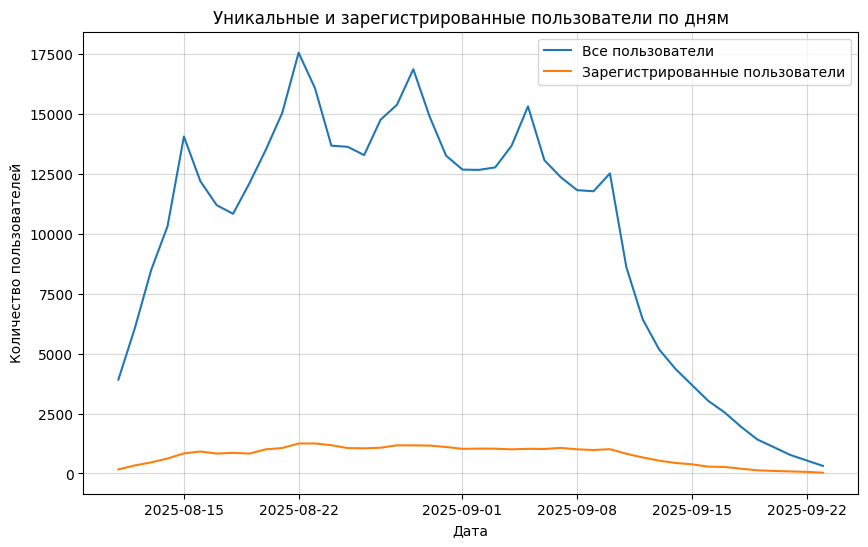

In [14]:
fig, ax1 = plt.subplots(figsize=(10, 6))
# линейный график (отображение уникальных пользователей)
sns.lineplot(
    data=df_sessions_history_unique_users,
    x='session_date',
    y='user_id',
    label='Все пользователи'
)
ax1.set_ylabel('Количество пользователей')
# линейный график (отображение зарегистрированных пользователей)
sns.lineplot(
    data=df_sessions_history_registrated_users,
    x='session_date',
    y='user_id',
    label='Зарегистрированные пользователи'
)
plt.title('Уникальные и зарегистрированные пользователи по дням')
plt.xlabel('Дата')
plt.grid(axis='both', alpha=0.5)
plt.legend()
plt.show()

In [15]:
df_sessions_history_registrated_users['percent'] = (df_sessions_history_registrated_users['user_id'] / df_sessions_history_unique_users['user_id'])
display(df_sessions_history_registrated_users)

,session_date,user_id,percent
0,2025-08-11,169,0.043123
1,2025-08-12,336,0.055482
2,2025-08-13,464,0.054659
3,2025-08-14,625,0.060556
4,2025-08-15,840,0.059723
5,2025-08-16,916,0.075051
6,2025-08-17,833,0.074375
7,2025-08-18,860,0.079343
8,2025-08-19,831,0.068576
9,2025-08-20,1008,0.074589


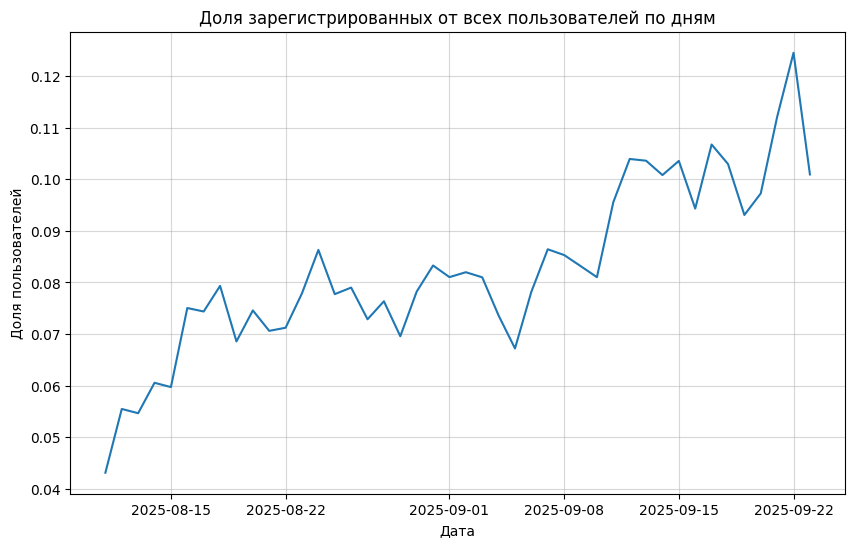

In [16]:
fig, ax1 = plt.subplots(figsize=(10, 6))
# линейный график (отображение уникальных пользователей)
sns.lineplot(
    data=df_sessions_history_registrated_users,
    x='session_date',
    y='percent',
)
ax1.set_ylabel('Доля пользователей')

plt.title('Доля зарегистрированных от всех пользователей по дням')
plt.xlabel('Дата')
plt.grid(axis='both', alpha=0.5)
plt.show()

<div style="background-color: #fcfcfc; color: #242424; padding: 10px; border-radius: 5px; border: 2px solid #dedede;">

После анализа числа общего количества пользователей, а так же общего числа зарегистрированных пользователей и нахождения их доли можно сказать, что хоть график доли зарегистрированных пользователей имеет восходящий тренд, однако этот рост обусловлен снижением общего числа пользователей (что видно на первом графике).  

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

- Найдем количество сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Построем столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

In [17]:
# группировка по пользователям и расчет количества уникальных сессий
page_counter_sessions = (df_sessions_history.groupby('page_counter')['session_id']
                   .count()
                   .reset_index())
page_counter_sessions['percent'] = (page_counter_sessions['session_id'] / page_counter_sessions['session_id'].sum() * 100).round(2)
display(page_counter_sessions)

,page_counter,session_id,percent
0,1,29160,6.69
1,2,105536,24.21
2,3,166690,38.24
3,4,105569,24.22
4,5,26288,6.03
5,6,2589,0.59
6,7,92,0.02


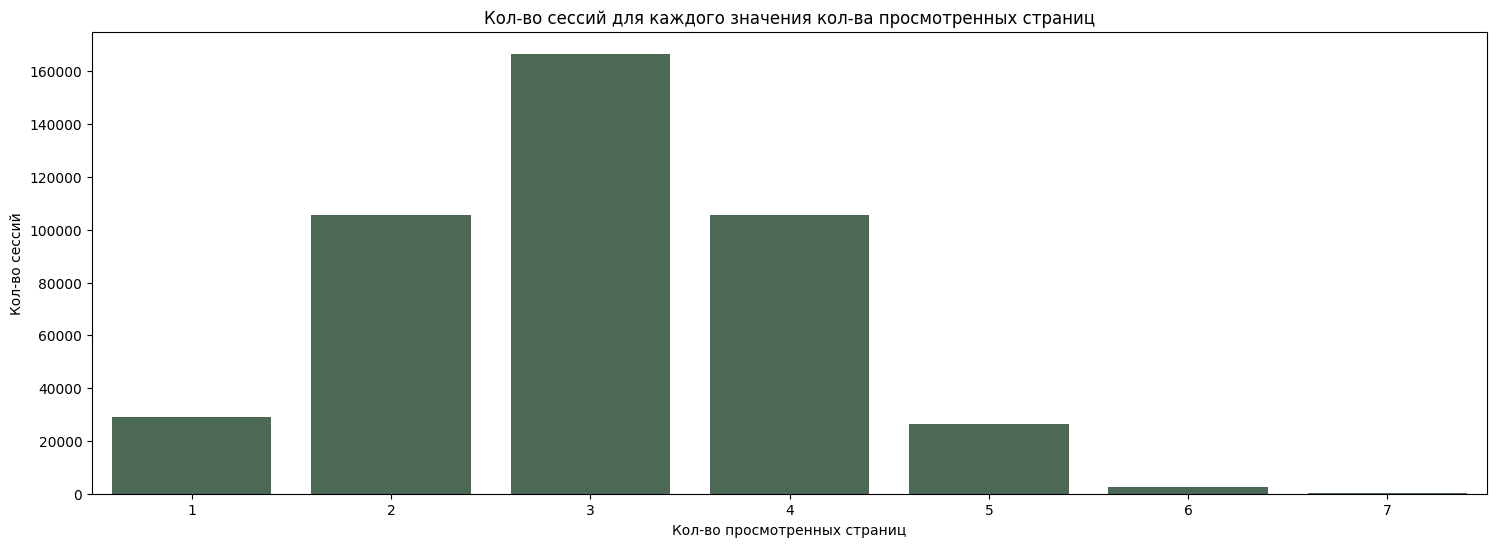

In [18]:
fig, ax1 = plt.subplots(figsize=(18, 6))
# столбчатая диаграмма
sns.barplot(
    data=page_counter_sessions,
    x='page_counter',
    y='session_id',
    color='#335e41',
    alpha=0.9,
)
ax1.set_ylabel('Кол-во сессий')
ax1.set_xlabel('Кол-во просмотренных страниц')
plt.title('Кол-во сессий для каждого значения кол-ва просмотренных страниц')
plt.show()

<div style="background-color: #fcfcfc; color: #242424; padding: 10px; border-radius: 5px; border: 2px solid #dedede;">

В результате видим, что самое большое количество сессий закончилось после просмотра 3 страниц (это 38.24% от общего количества сессий), всего в 0.02% сессий были просмотрены 7 страниц. 2 и 4 страницы посмотрели почти в одинаковом соотношении - 24.21% и 24.22% соответственно.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Построем график со средним значением доли успешных сессий от всех сессий по дням за весь период наблюдения.

In [19]:
# создаем новый столбец 'good_session'
df_sessions_history['good_session'] = (df_sessions_history['page_counter'] >= 4).astype(int)
display(df_sessions_history)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,good_session
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone,0
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android,1
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC,1
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android,1
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android,0
...,...,...,...,...,...,...,...,...,...,...,...
435919,769BC199AF26FEF8,914903B51D69C5EA,2025-09-17,2025-09-17 21:33:57,2025-09-04,3,1,3,CIS,PC,0
435920,599DED39F3CD2ADE,66ADBE343C94DCDA,2025-09-17,2025-09-17 17:11:46,2025-09-04,4,0,4,MENA,iPhone,1
435921,1FA20C4BC94E64B2,C4CCD7E81733665F,2025-09-17,2025-09-17 19:36:55,2025-09-04,4,0,4,CIS,Android,1
435922,88E5FC3016A7A0AD,6834FB4914B56200,2025-09-17,2025-09-17 22:13:33,2025-09-04,5,0,4,MENA,PC,1


In [20]:
# группировка по пользователям и расчет количества уникальных сессий
good_session_part = (df_sessions_history.groupby('session_date')
                .agg(count = ('good_session', 'count'), avg_good_session=('good_session', 'mean'))  
                .reset_index())
display(good_session_part)

,session_date,count,avg_good_session
0,2025-08-11,3919,0.312835
1,2025-08-12,6056,0.302015
2,2025-08-13,8489,0.306750
3,2025-08-14,10321,0.316055
4,2025-08-15,14065,0.304941
5,2025-08-16,12205,0.306186
6,2025-08-17,11200,0.317589
7,2025-08-18,10839,0.310545
8,2025-08-19,12118,0.312840
9,2025-08-20,13514,0.306941


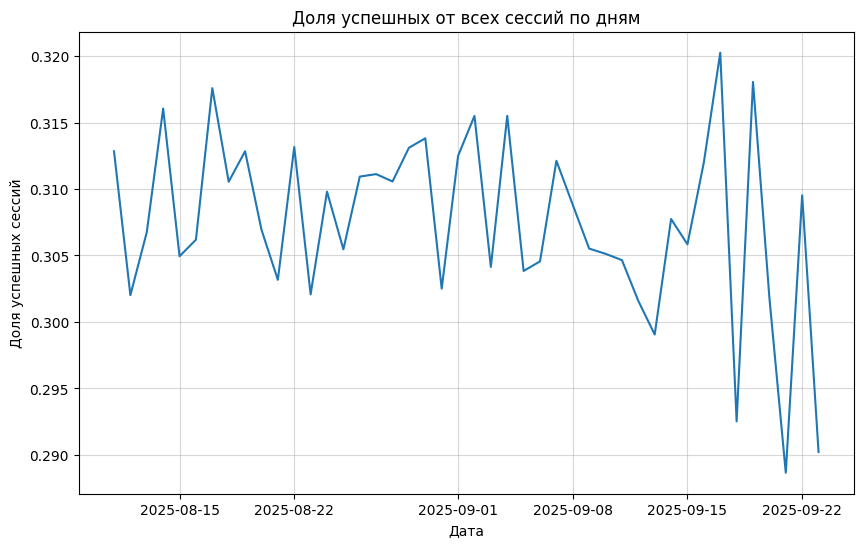

In [21]:
fig, ax1 = plt.subplots(figsize=(10, 6))
# линейный график
sns.lineplot(
    data=good_session_part,
    x='session_date',
    y= 'avg_good_session'
)
ax1.set_ylabel('Доля успешных сессий')

plt.title('Доля успешных от всех сессий по дням')
plt.xlabel('Дата')
plt.grid(axis='both', alpha=0.5)
plt.show()


<div style="background-color: #fcfcfc; color: #242424; padding: 10px; border-radius: 5px; border: 2px solid #dedede;">

В соответствии с графиком, можно сделать вывод о том, что средняя доля успешных сессий (где в рамках сессии было просмотрено 4 и более страниц) составляет от 29% до 32%. С 15 сентября наблюдается высокая волатильность значений день ото дня относительно предыдущего перидода.  

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Сформулировать нулевую и альтернативную гипотезы

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1 Формулировка нулевой и альтернативной гипотез

<div style="background-color: #fcfcfc; color: #242424; padding: 10px; border-radius: 5px; border: 2px solid #dedede;">

Учитывая, что монетизация приложения происходит как за счет зарегистрированных пользователей, так за счет незарегистрированных, а так же учитывая прокси-метрику (количество успешных сессий (4+ просмотров страниц за одну сессию)), думаю в качестве ключевой метрики можно использовать - количество успешных сессий в день, т.к. увеличение этого показателя положительно повлияет на выручку компании и приведет к большей вовлеченности пользователей.   Гипотезы будут следующие:
- H<sub>0</sub> (нулевая гипотеза) - количество успешных сессий в день в среднем **не различается** между тестовой и контрольной группами;
- H<sub>1</sub> (альтернативная гипотеза) - количество успешных сессий в день в среднем **различается** между тестовой и контрольной группами;

#### 2.2. Расчёт размера выборки
Рассчитаем необходимое для эксперимента количество пользователей.

Для этого установим в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используем метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

In [22]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03 * p  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.3. Расчёт длительности A/B-теста

Используем данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитаем длительность теста, разделив одно на другое.

- Рассчитаем среднее количество уникальных пользователей приложения в день.

- Определим длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлим в большую сторону.

In [23]:
from math import ceil

# среднее количество пользователей приложения в день по историческим данным
avg_daily_users = df_sessions_history.groupby('session_date')['user_id'].nunique().mean()

# рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size*2/avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")


Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие нас метрики корректно считаются.

- Считаем и сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаем и выведем на экран процентную разницу в количестве пользователей в группах A и B. Построем визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуемся формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [24]:
# загружаем данные датасета
try:
    # смотрим есть ли локальный файл
    df_sessions_test_part = pd.read_csv("sessions_project_test_part.csv", sep=',', skiprows=0, on_bad_lines='error')
except:
    # если же его нет:
    df_sessions_test_part = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test_part.csv')

In [25]:
# проверяем результат
df_sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [26]:
# смотрим, есть ли пропуски, правильно ли установился тип данных
df_sessions_test_part.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3130 entries, 0 to 3129
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            3130 non-null   object
 1   session_id         3130 non-null   object
 2   session_date       3130 non-null   object
 3   session_start_ts   3130 non-null   object
 4   install_date       3130 non-null   object
 5   session_number     3130 non-null   int64 
 6   registration_flag  3130 non-null   int64 
 7   page_counter       3130 non-null   int64 
 8   region             3130 non-null   object
 9   device             3130 non-null   object
 10  test_group         3130 non-null   object
dtypes: int64(3), object(8)
memory usage: 269.1+ KB


In [27]:
# в задании сказано, что данные готовы за 3 дня, проверяем датасет (данные представлены только за один день)
df_sessions_test_part['session_date'].unique()

array(['2025-10-14'], dtype=object)

In [28]:
df_sessions_test_part_unique_users = (df_sessions_test_part.groupby('test_group')['user_id']
                   .nunique()
                   .reset_index()
                    )
display(df_sessions_test_part_unique_users)

,test_group,user_id
0,A,1477
1,B,1466


In [29]:
a_users = df_sessions_test_part[df_sessions_test_part['test_group'] == 'A']['user_id'].nunique()
b_users = df_sessions_test_part[df_sessions_test_part['test_group'] == 'B']['user_id'].nunique()

a_b_users_dif = 100 * ((a_users - b_users) / b_users)
print(f"Процентная разница в количестве пользователей в группах A и B: {round(a_b_users_dif, 2)}%")

Процентная разница в количестве пользователей в группах A и B: 0.75%


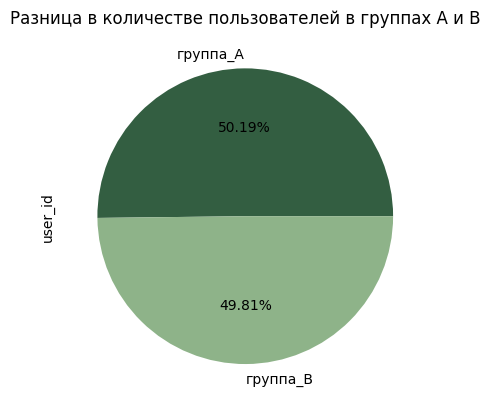

In [30]:
df_sessions_test_part_unique_users.plot(kind='pie', y='user_id',
                                                labels=["группа_A", "группа_B"], 
                                                autopct = "%1.2f%%", 
                                                colors = ["#335e41", "#8eb389"],
                                                )
# Настраиваем график
plt.title('Разница в количестве пользователей в группах A и B') # Заголовок диаграммы
plt.legend().set_visible(False)
# Отображаем график
plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитаем количество пользователей, которые встречаются одновременно в группах A и B, или убедимся, что таких нет.

In [31]:
!pip install matplotlib-venn -q 
from matplotlib_venn import venn2

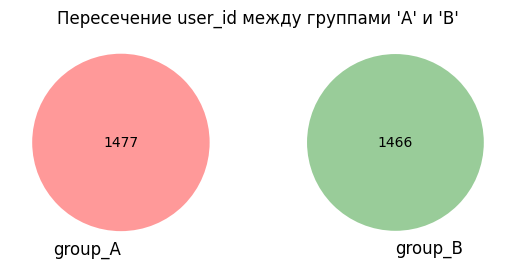

In [32]:
venn2([set(df_sessions_test_part[df_sessions_test_part['test_group'] == 'A']['user_id']), 
       set(df_sessions_test_part[df_sessions_test_part['test_group'] == 'B']['user_id'])], 
      set_labels=('group_A', 'group_B'))
plt.title("Пересечение user_id между группами 'A' и 'B'") 
plt.show()

<div style="background-color: #fcfcfc; color: #242424; padding: 10px; border-radius: 5px; border: 2px solid #dedede;">

По результатам работы с данными о сессиях пользователей `sessions_project_test_part.csv`:
- создали новый датафрейм  `df_sessions_test_part`;
- расчитали количество уникальных пользователей в каждой из экспериментальных групп, получилось **1477 пользователей в группе А** и **1466 пользователей в группе В**;
- процентная разница в количестве пользователей в группах A и B составила - 0.75%;
- с помощю диаграммы Венна убедились в независимости групп (пересечений между кругами не наблюдается).

#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Построем две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.


In [33]:
device_groupby_test_group_a = df_sessions_test_part[df_sessions_test_part['test_group'] == 'A'].groupby('device').agg({'user_id': 'nunique'}).reset_index()
device_groupby_test_group_a['part'] = (device_groupby_test_group_a['user_id'] / device_groupby_test_group_a['user_id'].sum()).round(2)
display(device_groupby_test_group_a)

,device,user_id,part
0,Android,656,0.44
1,Mac,156,0.11
2,PC,369,0.25
3,iPhone,296,0.20


In [34]:
device_groupby_test_group_b = df_sessions_test_part[df_sessions_test_part['test_group'] == 'B'].groupby('device').agg({'user_id': 'nunique'}).reset_index()
device_groupby_test_group_b['part'] = (device_groupby_test_group_b['user_id'] / device_groupby_test_group_b['user_id'].sum()).round(2)
display(device_groupby_test_group_b)

,device,user_id,part
0,Android,668,0.46
1,Mac,148,0.10
2,PC,381,0.26
3,iPhone,269,0.18


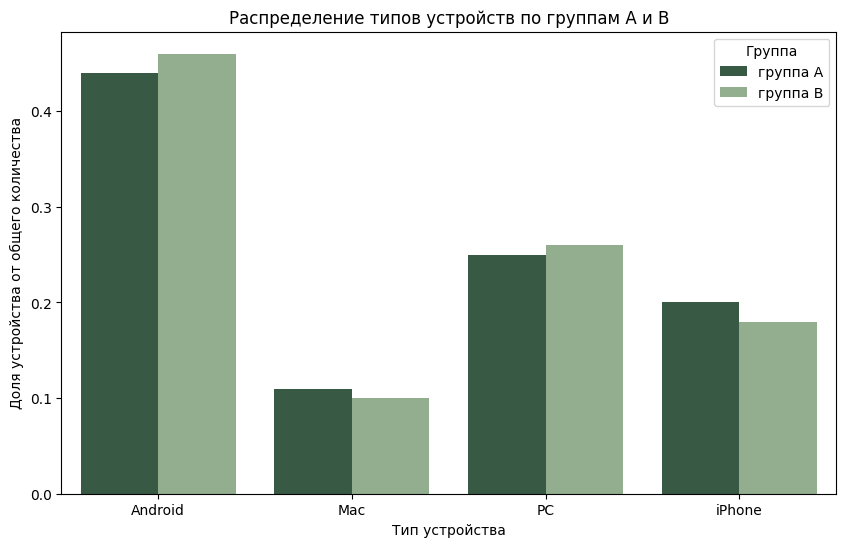

In [60]:
# объединяем данные, добавив колонку с указанием группы
device_groupby_test_group_a['group'] = 'группа А'
device_groupby_test_group_b['group'] = 'группа В'
combined_data = pd.concat([device_groupby_test_group_a, device_groupby_test_group_b])

# Создаем график
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=combined_data,
    x='device',
    y='part',
    hue='group',
    palette={'группа А': '#335e41', 'группа В': '#8eb389'}
)
plt.title('Распределение типов устройств по группам А и В')
plt.xlabel('Тип устройства')
plt.ylabel('Доля устройства от общего количества')
plt.legend(title='Группа')
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.

Построем две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.


In [36]:
region_groupby_test_group_a = df_sessions_test_part[df_sessions_test_part['test_group'] == 'A'].groupby('region').agg({'user_id': 'nunique'}).reset_index()
region_groupby_test_group_a['part'] = (region_groupby_test_group_a['user_id'] / region_groupby_test_group_a['user_id'].sum()).round(3)
display(region_groupby_test_group_a)

,region,user_id,part
0,CIS,644,0.436
1,EU,224,0.152
2,MENA,609,0.412


In [37]:
region_groupby_test_group_b = df_sessions_test_part[df_sessions_test_part['test_group'] == 'B'].groupby('region').agg({'user_id': 'nunique'}).reset_index()
region_groupby_test_group_b['part'] = (region_groupby_test_group_b['user_id'] / region_groupby_test_group_b['user_id'].sum()).round(3)
display(region_groupby_test_group_b)

,region,user_id,part
0,CIS,645,0.440
1,EU,217,0.148
2,MENA,604,0.412


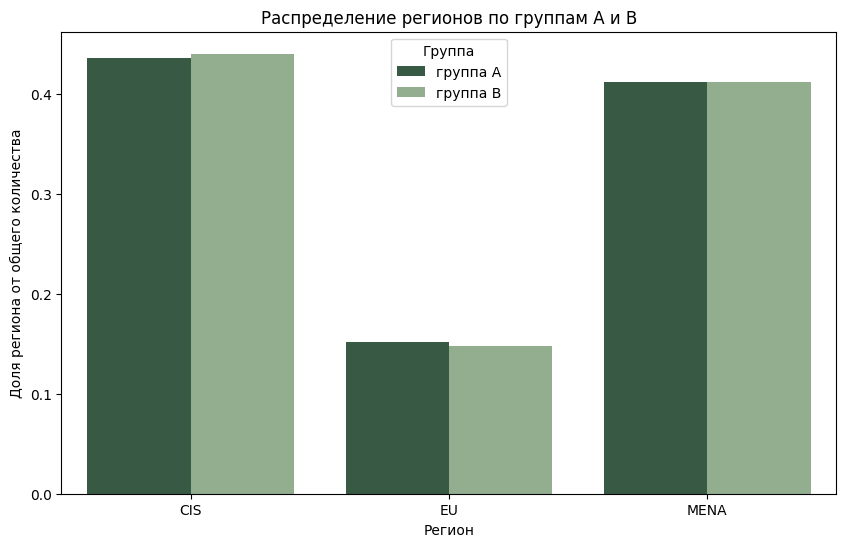

In [61]:
# объединяем данные, добавив колонку с указанием группы
region_groupby_test_group_a['group'] = 'группа А'
region_groupby_test_group_b['group'] = 'группа В'
combined_data = pd.concat([region_groupby_test_group_a, region_groupby_test_group_b])

# Создаем график
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=combined_data,
    x='region',
    y='part',
    hue='group',
    palette={'группа А': '#335e41', 'группа В': '#8eb389'}
)
plt.title('Распределение регионов по группам А и В')
plt.xlabel('Регион')
plt.ylabel('Доля региона от общего количества')
plt.legend(title='Группа')
plt.show()

#### 3.5. Вывод после проверки A/B-теста


<div style="background-color: #fcfcfc; color: #242424; padding: 10px; border-radius: 5px; border: 2px solid #dedede;">

По результатам работы с данными о сессиях пользователей `sessions_project_test_part.csv`:
- создали новый датафрейм  `df_sessions_test_part`;
- расчитали количество уникальных пользователей в каждой из экспериментальных групп, получилось **1477 пользователей в группе А** и **1466 пользователей в группе В**;
- процентная разница в количестве пользователей в группах A и B составила - 0.75%;
- с помощю диаграммы Венна убедились в независимости групп (пересечений между кругами не наблюдается);
- в резултате проверки убедились в равномерности распределения пользователей по всем доступным категориальным переменным — типам устройств и регионам.   

Учитывая наши данные, которые были получены в результате проверки А/В теста, можно сказать, что эксперимент проходит успешно.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у нас есть результаты за все дни проведения эксперимента. Убедимся в корректности теста и интерпретируем результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считаем и сохраним в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [62]:
# загружаем данные датасета
try:
    # смотрим есть ли локальный файл
    df_sessions_test = pd.read_csv("sessions_project_test.csv", sep=',', skiprows=0, on_bad_lines='error')
except:
    # если же его нет:
    df_sessions_test = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test.csv')

In [40]:
df_sessions_test['good_session'] = (df_sessions_test['page_counter'] >= 4).astype(int)
display(df_sessions_test)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0
...,...,...,...,...,...,...,...,...,...,...,...,...
100000,CF77C27B238C1BE3,0F7BC9B33685377C,2025-10-22,2025-10-22 19:01:50,2025-10-20,3,0,3,MENA,Android,A,0
100001,D7ED66C581409AC2,26C4475005E70F47,2025-10-17,2025-10-17 22:12:38,2025-10-17,1,0,5,CIS,PC,A,1
100002,E7EA2D51238020C6,9B9CDE6A612CBD73,2025-10-24,2025-10-24 14:54:07,2025-10-14,2,0,3,MENA,PC,B,0
100003,8A6FEFD7F34C5DA1,37291EC27106EF9D,2025-10-18,2025-10-18 00:05:10,2025-10-14,3,0,4,EU,Android,B,1


#### 4.2. Проверка корректности результатов теста

Прежде чем приступать к анализу ключевых продуктовых метрик, убедимся, что тест проведён корректно и мы будем сравнивать две сопоставимые группы.

- Рассчитаем количество уникальных сессий для каждого дня и обеих тестовых групп, используя группировку.

- Проверим, что количество уникальных дневных сессий в двух выборках не различается или различия не статистически значимыми. Используем статистический тест, который позволит сделать вывод о равенстве средних двух выборок.

In [43]:
# рассчитываем количество уникальных сессий для каждого дня и группы
daily_sessions = df_sessions_test.groupby(['session_date', 'test_group'])['session_id'].nunique().reset_index()
daily_sessions.columns = ['session_date', 'test_group', 'session_count']
daily_sessions.head()

,session_date,test_group,session_count
0,2025-10-14,A,1502
1,2025-10-14,B,1628
2,2025-10-15,A,2235
3,2025-10-15,B,2283
4,2025-10-16,A,3280


In [99]:
# разделяем данные по группам A и B
group_a_sessions = daily_sessions[daily_sessions['test_group'] == 'A']['session_count']
group_b_sessions = daily_sessions[daily_sessions['test_group'] == 'B']['session_count']

<div style="background-color: #fcfcfc; color: #242424; padding: 10px; border-radius: 5px; border: 2px solid #dedede;">

Перед проведением теста сформируем нулевую и альтернативную гипотезу: 
- H<sub>0</sub> (нулевая гипотеза) - количество уникальных дневных сессий **не различается** между группами A и B;
- H<sub>1</sub> (альтернативная гипотеза) - количество уникальных дневных сессий **различается** между группами A и B;

In [101]:
from scipy.stats import ttest_ind

In [103]:
# проводим t-тест для проверки равенства средних двух выборок
t_stat, p_value = ttest_ind(group_a_sessions, group_b_sessions, equal_var=False)

# выводим p-value и интерпретируем результат
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("P-value < 0.05: Есть статистически значимые различия в количестве уникальных дневных сессий между группами A и B.")
    print("Это может указывать на проблему в распределении пользователей или сессий.")
else:
    print("P-value >= 0.05: Нет статистически значимых различий в количестве уникальных дневных сессий между группами A и B.")
    print("Группы сопоставимы по количеству сессий, тест проведен корректно.")

P-value: 0.9382
P-value >= 0.05: Нет статистически значимых различий в количестве уникальных дневных сессий между группами A и B.
Группы сопоставимы по количеству сессий, тест проведен корректно.


#### 4.3. Сравнение доли успешных сессий

Переходим к анализу ключевой метрики — доли успешных сессий.

Используем созданный на первом шаге задания столбец `good_session` и рассчитаем долю успешных сессий для выборок A и B, а также разницу в этом показателе.

In [47]:
group_sessions_test = df_sessions_test.groupby('test_group').agg(
    total_sessions=('session_id', 'count'),
    good_sessions=('good_session', 'sum')
).reset_index()

group_sessions_test['good_session_part'] = group_sessions_test['good_sessions'] / group_sessions_test['total_sessions']

display(group_sessions_test)

,test_group,total_sessions,good_sessions,good_session_part
0,A,49551,15248,0.307723
1,B,50454,16059,0.318290


In [51]:
# записываем в переменную нужное нам значение из столбца 'good_session_part' каждой группы пользователей
good_session_part_a = group_sessions_test[group_sessions_test['test_group'] == 'A']['good_session_part'].iloc[0]
good_session_part_b = group_sessions_test[group_sessions_test['test_group'] == 'B']['good_session_part'].iloc[0]

# вычисляем разницу долей
difference = good_session_part_b - good_session_part_a

print(f"Разница между долями успешных сессий для выборок A и B: {difference:.4f} или {difference * 100:.2f}%")

Разница между долями успешных сессий для выборок A и B: 0.0106 или 1.06%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге мы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных сессий статистически значимым.


<div style="background-color: #fcfcfc; color: #242424; padding: 10px; border-radius: 5px; border: 2px solid #dedede;">

Перед проведением теста сформируем нулевую и альтернативную гипотезу: 
- H<sub>0</sub> (нулевая гипотеза) - доля успешных сессий **не различается** между группами A и B;
- H<sub>1</sub> (альтернативная гипотеза) - доля успешных сессий **различается** между группами A и B;

In [57]:
from statsmodels.stats.proportion import proportions_ztest

In [59]:
# проводим z-тест для пропорций
stat, p_value = proportions_ztest(
    count=group_sessions_test['good_sessions'],  # Количество успехов: [good_sessions_a, good_sessions_b]
    nobs=group_sessions_test['total_sessions'],  # Общее количество: [total_sessions_a, total_sessions_b]
    alternative='two-sided'  # Проверяем, что доля в A отличается от B (H₁: (μ_A ≠ μ_B))
)

# Выводим p-value и интерпретируем результат
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("P-value < 0.05: Есть статистически значимые основания отвергнуть H₀ на уровне значимости 5%.")
    print("Различие в доле успешных сессий между группами A и B является статистически значимым.")
else:
    print("P-value >= 0.05: Нет статистически значимых оснований отвергнуть H₀ на уровне значимости 5%.")
    print("Различие в доле успешных сессий между группами A и B не является статистически значимым.")

P-value: 0.0003
P-value < 0.05: Есть статистически значимые основания отвергнуть H₀ на уровне значимости 5%.
Различие в доле успешных сессий между группами A и B является статистически значимым.


#### 4.5. Вывод по результатам A/B-эксперимента

<div style="background-color: #fcfcfc; color: #242424; padding: 10px; border-radius: 5px; border: 2px solid #dedede;">

Целью нашего A/B-эксперимента была проверка нового алгоритма рекомендаций, который, по мнению разработчиков, будет показывать более интересный контент для каждого пользователя.  

По результатам теста, можно сказать следующее: </br>  
**Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента:** </br> 
 - выборка составила - 82 080 пользователей (расчитанный размер выборки для каждой группы - 41 040);
 - длительность A/B-теста при текущем уровене трафика в 9 907 пользователей в день, составила - 9 дней.</br>
   
**Влияние внедрения нового алгоритма рекомендаций на рост ключевой метрики:** </br>  
- в результате расчетов, было обнаружено увеличение доли успешных сессий на 1.06% в группе B относительно группы А, что говорит о росте вовлеченности пользователей.</br>
  
**Оценка статистической значимости выявленного эффекта:** </br>  
 - статистическая значимость оценивалась с помощью z-теста;
 - полученное значение p-value составило 0.0003, что позволило отвергнуть H₀ на уровне значимости 5% и сделать вывод, что различие в доле успешных сессий между группами A и B является статистически значимым. </br>
   
**Целесообразность внедрения нововведения в приложение:** </br>  
 - учитывая положительный эффект от нового алгоритма рекомендаций (доля успешных сессий увеличилась на 1.06%) допустимо его внедрение. Однако принимая во внимание, что этот эффект меньше минимального детектируемого эффекта MDE — 3%, стоит просчитать экономическую составляющую внедрения. Возможно затраты окажутся выше чем дивиденды от внедрения. Так же возможно стоит проверить другие метрики продукта и оценить влияние нового алгоритма на них.
